# LINEAR REGRESSION

In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
data_df = pd.read_csv("data_cleaned.csv")
print(f"Loaded {len(data_df)} rows, {len(data_df.columns)} columns")
print(f"Columns: {list(data_df.columns)}")
data_df.head()

Loaded 1328 rows, 9 columns
Columns: ['age', 'bmi', 'children', 'charges', 'gender_encoded', 'smoker_encoded', 'region_northwest', 'region_southeast', 'region_southwest']


,age,bmi,children,charges,gender_encoded,smoker_encoded,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,1,1,0.0,0.0,1.0
1,18,33.770,1,1725.55230,0,0,0.0,1.0,0.0
2,28,33.000,3,4449.46200,0,0,0.0,1.0,0.0
3,33,22.705,0,21984.47061,0,0,1.0,0.0,0.0
4,32,28.880,0,3866.85520,0,0,1.0,0.0,0.0


## 1. Data Splitting

In [37]:
from sklearn.model_selection import train_test_split

data_df['smoker_bmi'] = data_df['smoker_encoded'] * data_df['bmi']
data_df['age_squared'] = data_df['age'] ** 2

feature_cols = ['age', 'age_squared', 'bmi', 'children', 'gender_encoded', 'smoker_encoded',
                'region_northwest', 'region_southeast', 'region_southwest',
                'smoker_bmi']

X = data_df[feature_cols]
y = data_df['charges']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set:     {X_test.shape[0]} samples")
print(f"\nFeatures ({len(feature_cols)}):")
for col in feature_cols:
    print(f"  - {col}")

Training set: 1062 samples
Test set:     266 samples

Features (10):
  - age
  - age_squared
  - bmi
  - children
  - gender_encoded
  - smoker_encoded
  - region_northwest
  - region_southeast
  - region_southwest
  - smoker_bmi


## 2. Model Training

In [38]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)

print("Linear Regression model trained successfully.")
print(f"Intercept: {model.intercept_:,.2f}")

Linear Regression model trained successfully.
Intercept: 1,840.02


## 3. Model Evaluation

In [39]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np

r2_train = r2_score(y_train, y_pred_train)
r2_test = r2_score(y_test, y_pred_test)

mse_train = mean_squared_error(y_train, y_pred_train)
mse_test = mean_squared_error(y_test, y_pred_test)

rmse_train = np.sqrt(mse_train)
rmse_test = np.sqrt(mse_test)

mae_train = mean_absolute_error(y_train, y_pred_train)
mae_test = mean_absolute_error(y_test, y_pred_test)

metrics = pd.DataFrame({
    'Metric': ['R²', 'MSE', 'RMSE', 'MAE'],
    'Train': [r2_train, mse_train, rmse_train, mae_train],
    'Test': [r2_test, mse_test, rmse_test, mae_test]
})

metrics['Train'] = metrics['Train'].apply(lambda x: f"{x:,.4f}" if x < 10 else f"{x:,.2f}")
metrics['Test'] = metrics['Test'].apply(lambda x: f"{x:,.4f}" if x < 10 else f"{x:,.2f}")

print("Model Performance:\n")
print(metrics.to_string(index=False))

Model Performance:

Metric         Train          Test
    R²        0.8411        0.8407
   MSE 23,048,056.95 22,143,462.85
  RMSE      4,800.84      4,705.68
   MAE      2,880.49      2,796.45


## 4. Feature Coefficients

Feature Coefficients (sorted by absolute value):

  smoker_encoded            :   -21,064.95
  region_southwest          :    -1,603.08
  region_southeast          :    -1,495.17
  smoker_bmi                :     1,474.13
  region_northwest          :      -804.69
  children                  :       757.12
  gender_encoded            :       580.17
  bmi                       :        31.40
  age                       :       -18.85
  age_squared               :         3.56


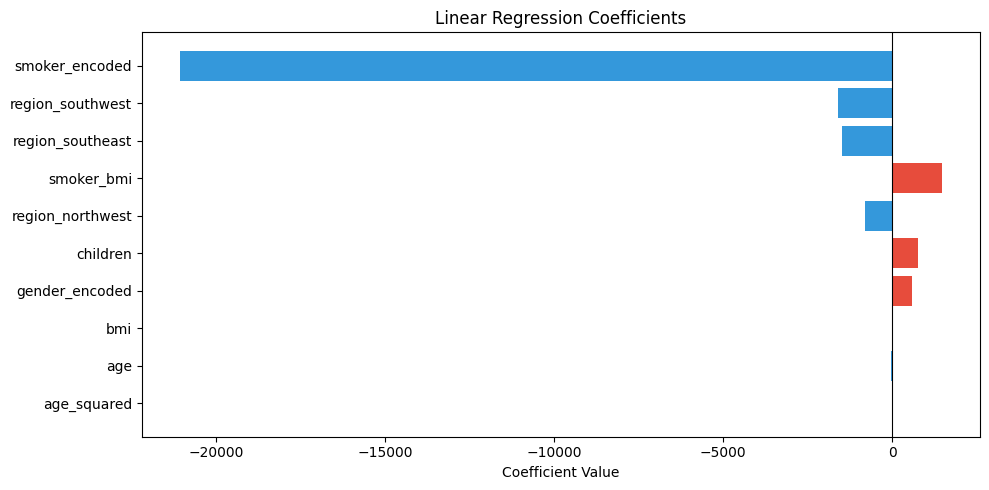

In [40]:
coef_df = pd.DataFrame({
    'Feature': feature_cols,
    'Coefficient': model.coef_
}).sort_values(by='Coefficient', key=abs, ascending=False)

print("Feature Coefficients (sorted by absolute value):\n")
for _, row in coef_df.iterrows():
    print(f"  {row['Feature']:25s} : {row['Coefficient']:>12,.2f}")

plt.figure(figsize=(10, 5))
colors = ['#e74c3c' if c > 0 else '#3498db' for c in coef_df['Coefficient']]
plt.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors)
plt.xlabel('Coefficient Value')
plt.title('Linear Regression Coefficients')
plt.axvline(x=0, color='black', linewidth=0.8)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## 5. Residual Analysis

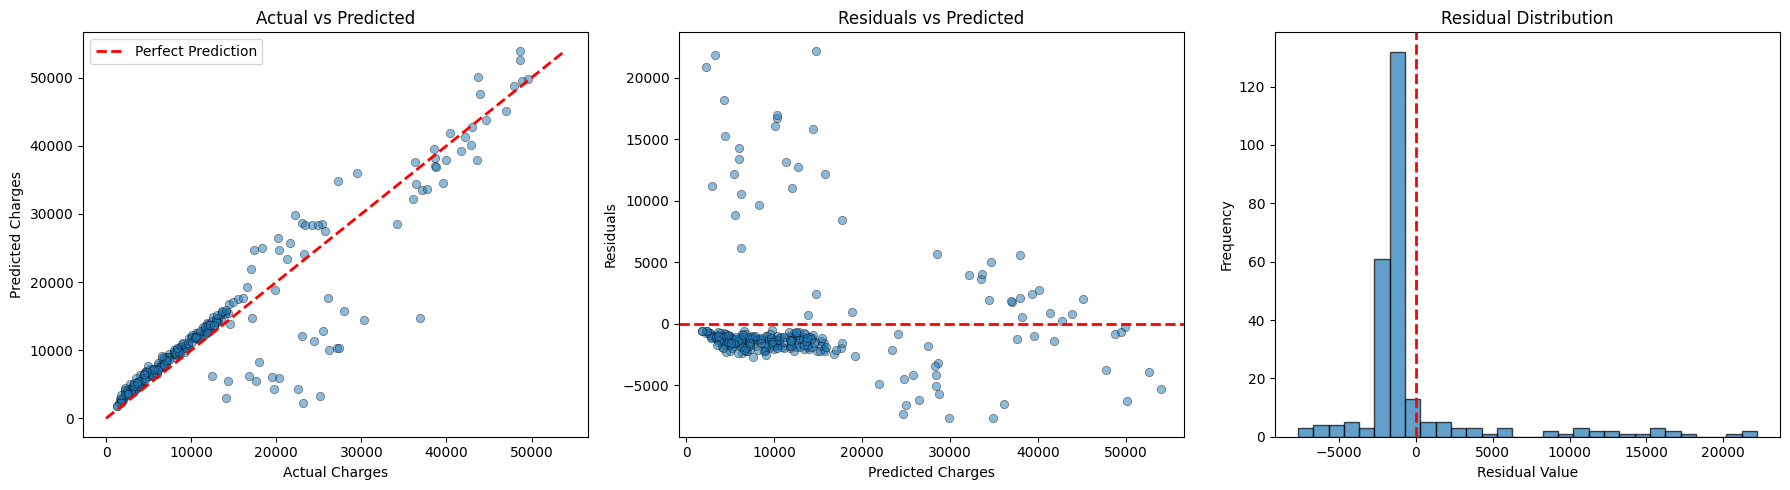

In [41]:
residuals = y_test - y_pred_test

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].scatter(y_test, y_pred_test, alpha=0.5, edgecolors='black', linewidths=0.5)
max_val = max(y_test.max(), y_pred_test.max())
axes[0].plot([0, max_val], [0, max_val], 'r--', linewidth=2, label='Perfect Prediction')
axes[0].set_xlabel('Actual Charges')
axes[0].set_ylabel('Predicted Charges')
axes[0].set_title('Actual vs Predicted')
axes[0].legend()

axes[1].scatter(y_pred_test, residuals, alpha=0.5, edgecolors='black', linewidths=0.5)
axes[1].axhline(y=0, color='r', linestyle='--', linewidth=2)
axes[1].set_xlabel('Predicted Charges')
axes[1].set_ylabel('Residuals')
axes[1].set_title('Residuals vs Predicted')

axes[2].hist(residuals, bins=30, edgecolor='black', alpha=0.7)
axes[2].axvline(x=0, color='r', linestyle='--', linewidth=2)
axes[2].set_xlabel('Residual Value')
axes[2].set_ylabel('Frequency')
axes[2].set_title('Residual Distribution')

plt.tight_layout()
plt.show()

## 6. Assumption Check

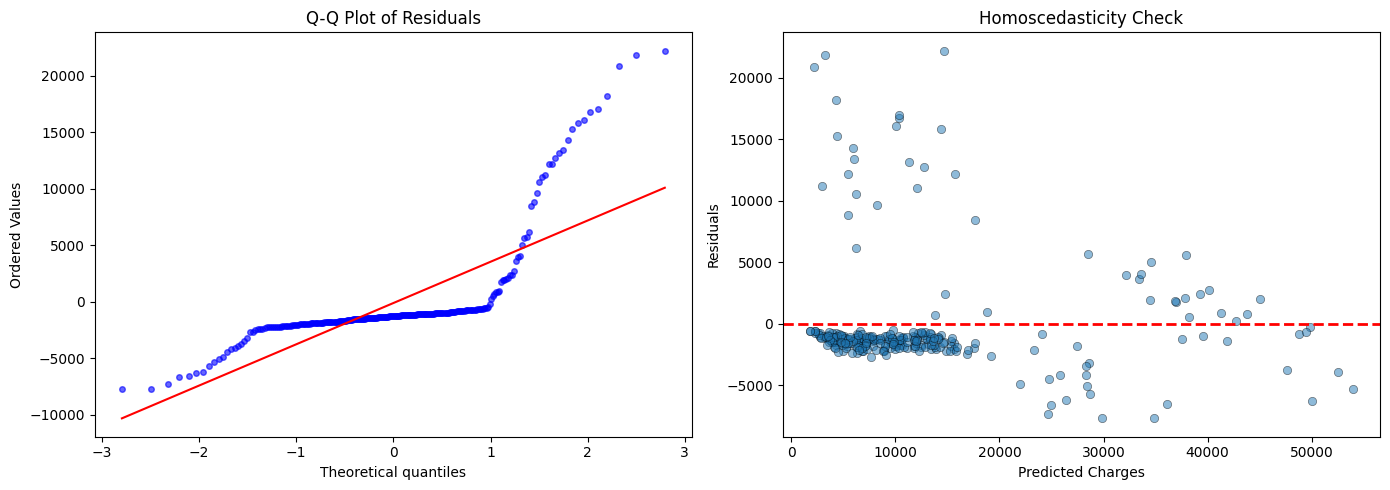


Shapiro-Wilk test on residuals:
  Statistic = 0.5950
  p-value   = 0.000000
  Result    : Residuals are NOT normally distributed

Residual Statistics:
  Mean:        -109.3372
  Std Dev:     4713.2816
  Skewness:       2.7604


In [42]:
from scipy.stats import shapiro
import scipy.stats as scipy_stats

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

scipy_stats.probplot(residuals, dist="norm", plot=axes[0])
axes[0].set_title('Q-Q Plot of Residuals')
axes[0].get_lines()[0].set(markersize=4, alpha=0.6)

axes[1].scatter(y_pred_test, residuals, alpha=0.5, edgecolors='black', linewidths=0.5)
axes[1].axhline(y=0, color='r', linestyle='--', linewidth=2)
axes[1].set_xlabel('Predicted Charges')
axes[1].set_ylabel('Residuals')
axes[1].set_title('Homoscedasticity Check')

plt.tight_layout()
plt.show()

stat, p_value = shapiro(residuals)
print(f"\nShapiro-Wilk test on residuals:")
print(f"  Statistic = {stat:.4f}")
print(f"  p-value   = {p_value:.6f}")
print(f"  Result    : {'Residuals are normally distributed' if p_value > 0.05 else 'Residuals are NOT normally distributed'}")
print(f"\nResidual Statistics:")
print(f"  Mean:     {residuals.mean():>12.4f}")
print(f"  Std Dev:  {residuals.std():>12.4f}")
print(f"  Skewness: {residuals.skew():>12.4f}")

# Linear Regression Summary

## Features Used (10)

| Feature | Type | Description |
|---------|------|-------------|
| age | Original | Patient age |
| age_squared | Polynomial | age²: captures non-linear age effect |
| bmi | Original | Body Mass Index |
| children | Original | Number of dependents |
| gender_encoded | Encoded | 0 = male, 1 = female |
| smoker_encoded | Encoded | 0 = no, 1 = yes |
| region_northwest | OneHot | Region dummy |
| region_southeast | OneHot | Region dummy |
| region_southwest | OneHot | Region dummy |
| smoker_bmi | Interaction | smoker_encoded × bmi |

## Model Performance

| Metric | Train | Test |
|--------|-------|------|
| R² | 0.8411 | 0.8407 |
| RMSE | $4,801 | $4,706 |
| MAE | $2,880 | $2,796 |

## What Worked

* **No overfitting**: Train-Test R² gap is only ~0.0004, indicating excellent generalization.
* **Interaction term `smoker_bmi`**: This was the single most impactful improvement, increasing R² from ~0.75 to ~0.84. It captures the fact that BMI has a much larger effect on charges for smokers than non-smokers.
* **Polynomial `age_squared`**: Provided a small R² improvement (~0.003) by capturing the non-linear relationship between age and charges.

## What Did NOT Work

* **`smoker_age` interaction**: Tested but removed because its coefficient was near zero (-0.64), contributing no meaningful improvement.
* **Log transformation on target**: Tested `y = np.log1p(charges)`, but it worsened performance significantly (R² dropped from 0.84 to 0.38 in original scale, RMSE doubled to ~$9,300). This is because the charges distribution is **bimodal** (smoker vs non-smoker clusters), not simply right-skewed. Log transform works best for continuous, monotonically skewed data, not data with distinct subpopulations.

## Remaining Limitations

* **Residuals are NOT normally distributed:**
  * Shapiro-Wilk statistic = 0.5950, p-value = 0.000000
  * Residual skewness = 2.76 (heavily right-skewed)
  * The model systematically under-predicts for high-cost patients

* **Heteroscedasticity** — Residual variance increases with predicted charges. This violates the constant-variance assumption of OLS regression.

* **Multicollinearity from interaction/polynomial terms:**
  * `smoker_encoded` has a negative coefficient (-21,065) despite being the strongest positive predictor. This is because its effect is split between `smoker_encoded` and `smoker_bmi`. The total smoker effect is: -21,065 + 1,474 × BMI (positive for BMI > ~14).
  * `age` has a negative coefficient (-18.85) due to correlation with `age_squared`. The total effect remains positive for all realistic ages.
  * This does not affect prediction accuracy but makes individual coefficient interpretation misleading.

## Conclusion

With interaction terms and polynomial features, the model achieves **R² ≈ 0.84** and **RMSE ≈ $4,700**, which is a strong result for linear regression on this dataset. The main remaining issue is the violation of residual normality and homoscedasticity assumptions, caused by the inherent **bimodal structure** of the charges distribution (smoker vs non-smoker). These issues are structural to the data and cannot be fully resolved within the linear regression framework.